# Owens-Bozic Pipeline Test

Replicate the pipeline from `owens_bozic_perf.py` using the new pident API.
This notebook demonstrates:
1. Synthetic data generation (parameter sampling, trajectory simulation, noise)
2. MONOLIX configuration file generation
3. Running MONOLIX estimation
4. Parsing results and computing metrics
5. Stratifying outcomes


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from numpy.random import Generator
from numpy.typing import ArrayLike

from pident.common.distributions import Constant, TruncLognorm, UnivarDist
from pident.estimation.mlx_config import (
    MlxResidualErrorParamConfig,
    MlxObsVarConfig,
    MlxParamConfig,
    generate_mlxtran_file,
)
from pident.estimation.mlx_estimation import run_monolix_estimation
from pident.lib.metrics import (
    compute_parameter_relative_error,
    compute_rms_per_variable_log10,
)
from pident.lib.owens_bozic_model import owens_bozic_model
from pident.lib.stratification import (
    stratify_by_final_value,
)
from pident.metrics.monolix_results import (
    parse_convergence_results,
    parse_estimated_parameters,
)
from pident.synthetic_data.dist_samplers import independent_sampler
from pident.synthetic_data.monolix_csv_writer import write_monolix_csv
from pident.synthetic_data.obs_noise import (
    add_noise,
    proportional_normal_error_model,
)
from pident.synthetic_data.obs_samplers import subsample_trajectories


## Pipeline Configuration


In [3]:
# Pipeline parameters
param_name_to_fit = "a"  # Which parameter to fit
n_pts = 10  # Number of observation timepoints
noise_level = 0.25  # Proportional noise level
n_indivs = 10  # Number of individuals
param_seed = 42
noise_seed = sum([ord(c) for c in param_name_to_fit]) + int(100 * noise_level * n_pts * n_indivs)

# File paths
data_dir = Path("ob_pipeline_data")
data_dir.mkdir(exist_ok=True)

csv_path = data_dir / "synthetic_data.csv"
mlxtran_name = "owens_bozic_pipeline"
mlxtran_path = data_dir / f"{mlxtran_name}.mlxtran"
model_path = data_dir / "owens_bozic.txt"
results_dir = data_dir / mlxtran_name

print(f"Pipeline config:")
print(f"  Parameter to fit: {param_name_to_fit}")
print(f"  n_pts={n_pts}, noise_level={noise_level}, n_indivs={n_indivs}")
print(f"  Output directory: {data_dir}")


Pipeline config:
  Parameter to fit: a
  n_pts=10, noise_level=0.25, n_indivs=10
  Output directory: ob_pipeline_data


## Define Parameter Distributions


In [4]:
param_dists: dict[str, UnivarDist] = {
    "a": TruncLognorm(median=0.2, mlx_omega=0.5, upper_bound=0.6),
    "b_inv": TruncLognorm(median=1.37e11, mlx_omega=1.14, upper_bound=1e13),
    "dE": TruncLognorm(median=2.22, mlx_omega=0.34),
    "dC": Constant(2.25),
    "g": Constant(1.03e4),
    "jE": Constant(1.56e-2),
    "jC": TruncLognorm(median=3.46e-1, mlx_omega=0.75),
    "K": Constant(5.21e8),
    "k": Constant(8.67e6),
    "l": TruncLognorm(median=1.418, mlx_omega=0.15),
    "mE": Constant(1.7e-2),
    "mC": Constant(0.293),
    "qE": TruncLognorm(median=1.28e-10, mlx_omega=1.35),
    "qC": TruncLognorm(median=2.14e-10, mlx_omega=2.6),
    "s": TruncLognorm(median=0.302, mlx_omega=0.17, upper_bound=1),
    "KT": Constant(7e-1),
    "KE": Constant(6e-1),
    "KC": Constant(6e-1),
    "gamma": Constant(9e-1),
}

obs_var_init_val_dists: dict[str, UnivarDist] = {
    "T": TruncLognorm(median=1.58e9, mlx_omega=1.5),
    "E": Constant(4e5),
    "C": TruncLognorm(median=6.3e7, mlx_omega=2.0),
    "M": TruncLognorm(median=6.0, mlx_omega=0.2),
}


In [5]:
def dists_to_independent_samples(
    dist_dict: dict[str, UnivarDist], rng: Generator, n_samples: int
) -> list[dict[str, float]]:
    """Independently sample from each distribution."""
    keys = dist_dict.keys()
    dists = [dist_dict[key] for key in keys]
    sampler = independent_sampler(dists)
    sampled_val_lists = [sampler(rng) for _ in range(n_samples)]
    return [
        {k: v for k, v in zip(keys, vals)} for vals in sampled_val_lists  # type: ignore
    ]


## Generate Synthetic Data


In [21]:
# Sample parameters and initial conditions
rng = np.random.default_rng(seed=param_seed)
param_val_dicts = dists_to_independent_samples(param_dists, rng, n_indivs)
init_val_dicts = dists_to_independent_samples(obs_var_init_val_dists, rng, n_indivs)

# Generate ground truth trajectories
start_day = 0
end_day = 100
ground_truths = [
    owens_bozic_model.get_ground_truth(
        param_val_dict, init_val_dict, start_day, end_day
    )
    for param_val_dict, init_val_dict in zip(param_val_dicts, init_val_dicts)
]

# Subsample trajectories at observation times

def _lerp(start: float, end: float, frac: float) -> float:
    return start * (1 - frac) + end * frac

midpt = _lerp(start_day, end_day, 0.2)
n_early_pts = n_pts // 2
obs_times = np.concat(
    (
        np.linspace(start_day, midpt, n_early_pts),
        np.linspace(midpt, end_day, n_pts - n_early_pts),
    )
)
scheds: dict[str, ArrayLike] = {
    obs_var: obs_times for obs_var in owens_bozic_model.obs_var_names
}
trajectories_all = [
    subsample_trajectories(ground_truth, scheds) for ground_truth in ground_truths
]

# Add noise
rng_noise = np.random.default_rng(seed=noise_seed)
error_models = {
    "T": proportional_normal_error_model(noise_level, 1e-2),
    "E": proportional_normal_error_model(noise_level, 1e-2),
    "C": proportional_normal_error_model(noise_level, 1e-2),
    "M": proportional_normal_error_model(noise_level, 1e-2),
}
noisy_trajectories_all = [
    add_noise(trajectories, error_models, rng_noise) for trajectories in trajectories_all
]

print(f"Generated {n_indivs} individuals with {n_pts} observation timepoints each")
print(f"Observation timepoints: {obs_times}")

Generated 10 individuals with 10 observation timepoints each
Observation timepoints: [  0.   5.  10.  15.  20.  20.  40.  60.  80. 100.]


### Plot Synthetic Data and Parameter Distributions


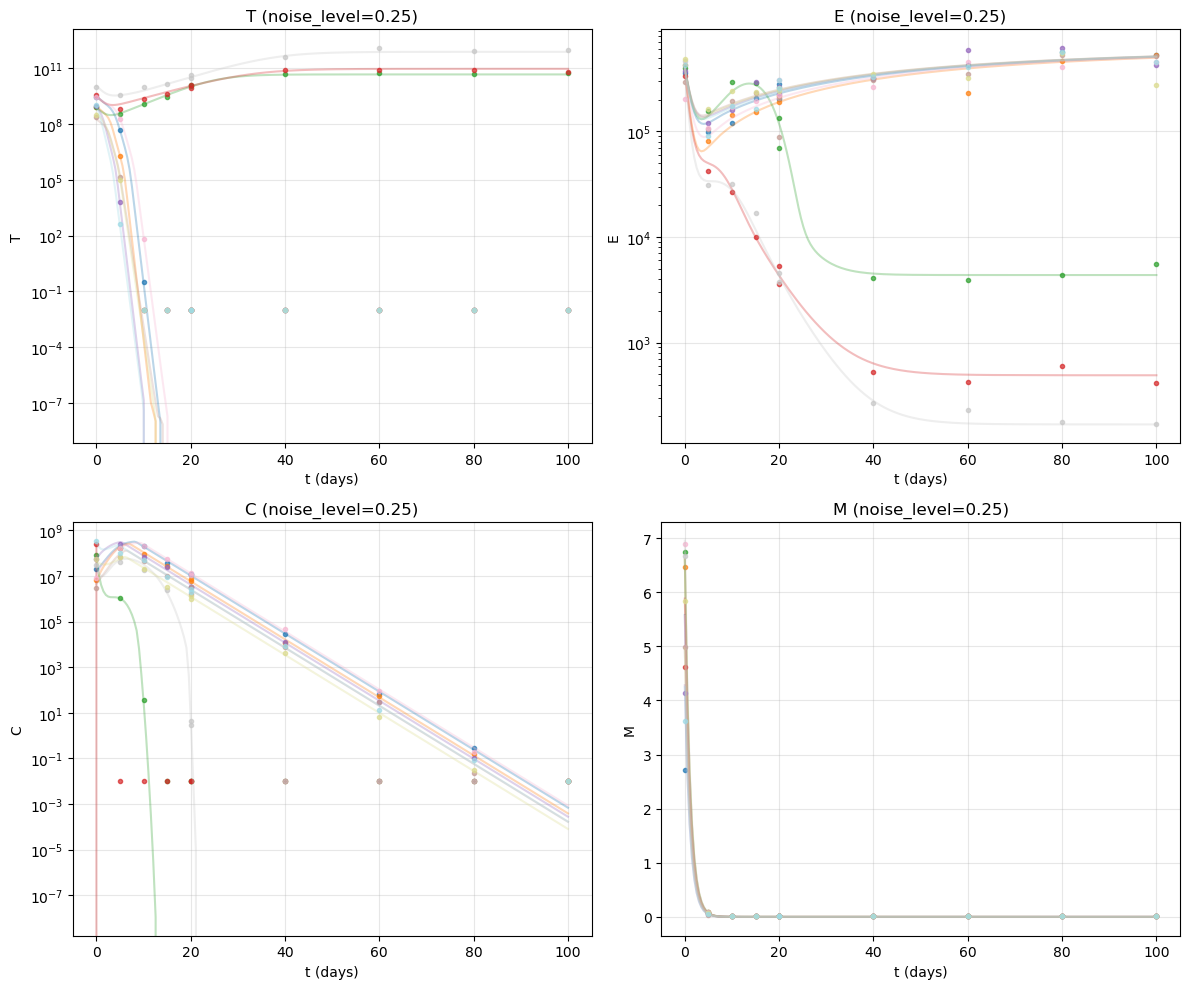

In [38]:
# Plot trajectories
t = np.linspace(start_day, end_day, 200)
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

colors = plt.cm.tab20(np.linspace(0, 1, n_indivs))

for i, (ground_truth, noisy_trajectories, color) in enumerate(
    zip(ground_truths, noisy_trajectories_all, colors)
):
    for obs_var, ax in zip(owens_bozic_model.obs_var_names, axs):
        if obs_var == "M":
            ax.plot(t, ground_truth(t)[obs_var], color=color, alpha=0.3)
            noisy_traj = noisy_trajectories[obs_var]
            ax.plot(noisy_traj["t"], noisy_traj["y"], "o", color=color, alpha=0.7, markersize=3)
        else:
            ax.semilogy(t, ground_truth(t)[obs_var], color=color, alpha=0.3)
            noisy_traj = noisy_trajectories[obs_var]
            ax.semilogy(
                noisy_traj["t"],
                noisy_traj["y"],
                "o",
                color=color,
                alpha=0.7,
                markersize=3,
            )
        ax.set_title(f"{obs_var} (noise_level={noise_level})")
        ax.set_xlabel("t (days)")
        ax.set_ylabel(f"{obs_var}")
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


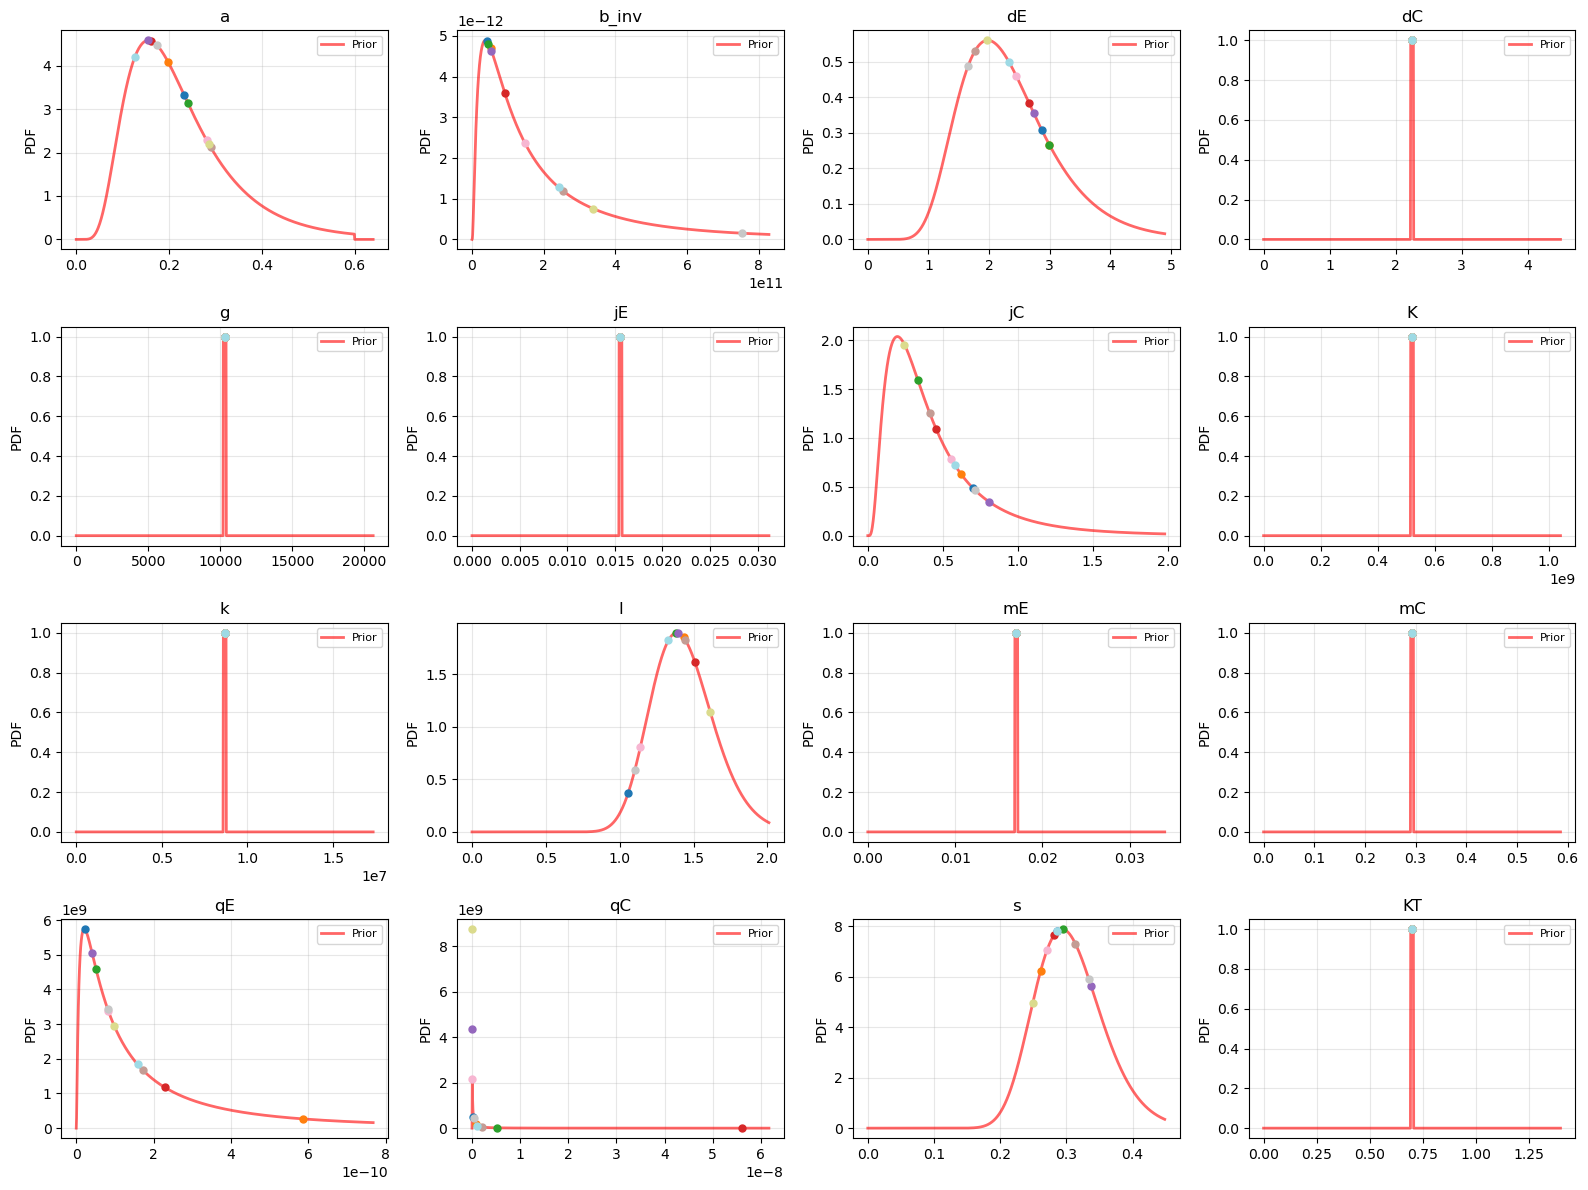

In [37]:
# Plot parameter distributions
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for ax, (param_name, dist) in zip(axes, param_dists.items()):
    lower, upper = dist.plot_bounds()
    upper = max(upper, 1.1 * max([d[param_name] for d in param_val_dicts]))
    x = np.linspace(lower, upper, 1000)
    ax.plot(x, dist.pdf(x), color="red", lw=2, alpha=0.6, label="Prior")
    
    for i, (param_val_dict, color) in enumerate(zip(param_val_dicts, colors)):
        param_val = param_val_dict[param_name]
        ax.plot(param_val, dist.pdf(param_val), "o", color=color, markersize=5)
    
    ax.set_title(param_name)
    ax.set_ylabel("PDF")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for i in range(len(param_dists), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


### Write CSV and Create MONOLIX Configuration


In [24]:
hidden_obs_vars = ["E", "M"]

# Write CSV file for Monolix
trajectories_per_patient = {
    f"patient_{i}": traj for i, traj in enumerate(noisy_trajectories_all)
}

def log10_transform(x: ArrayLike) -> ArrayLike:
    return np.log10(x)

transformations = {
    "T": log10_transform,
    "E": log10_transform,
    "C": log10_transform,
    "M": log10_transform,
}

write_monolix_csv(
    csv_path,
    trajectories_per_patient,
    ode_model=owens_bozic_model,
    transformations=transformations,
    hidden_obs_var_names=hidden_obs_vars,
)
print(f"Wrote CSV to {csv_path}")

# Create model parameter configs
# Parameters from owens_bozic_perf.py MODEL_PARAMS with (name, median, mlx_omega)
model_params: dict[str, MlxParamConfig] = {
    param_name: MlxParamConfig(
        dist_name="logNormal",
        init_est_pop=dist.median if hasattr(dist, "median") else 1.0,
        init_est_omega=dist.mlx_omega if hasattr(dist, "mlx_omega") else 0.1,
        is_fixed=(param_name != param_name_to_fit),
    )
    for param_name, dist in param_dists.items()
}

# Create observation variable configs
# Initial condition configs for each observation variable
obs_var_ic_configs: dict[str, MlxParamConfig] = {
    obs_var: MlxParamConfig(
        dist_name="logNormal",
        init_est_pop=obs_var_init_val_dists[obs_var].median,
        init_est_omega=obs_var_init_val_dists[obs_var].mlx_omega,
        is_fixed=True,  # Fix initial conditions during estimation
    )
    for obs_var in owens_bozic_model.obs_var_names
}

# Observation variable configs (pred_name mapping: T->TT, E->EEE, C->CCC, M->MM)
pred_name_map = {"T": "T" * 2, "E": "E" * 3, "C": "C" * 3, "M": "M" * 2}
obs_vars: dict[str, MlxObsVarConfig] = {
    obs_var: MlxObsVarConfig(
        pred_name=pred_name_map[obs_var],
        ic_config=obs_var_ic_configs[obs_var],
        residual_error_model_type="proportional",
        residual_error_dist_name="normal",
        residual_error_params=[
            MlxResidualErrorParamConfig(name="b", init_est=noise_level, is_fixed=False),
            MlxResidualErrorParamConfig(name="c", init_est=1, is_fixed=True),
        ],
    )
    for obs_var in owens_bozic_model.obs_var_names
}

# Generate mlxtran file
generate_mlxtran_file(
    output_path=mlxtran_path,
    data_csv_path=csv_path,
    mlx_model_path=model_path,
    ode_model=owens_bozic_model,
    model_params=model_params,
    obs_vars=obs_vars,
    hidden_obs_var_names=hidden_obs_vars,
)
print(f"Generated mlxtran file: {mlxtran_path}")


Wrote CSV to ob_pipeline_data\synthetic_data.csv
Generated mlxtran file: ob_pipeline_data\owens_bozic_pipeline.mlxtran


## Run MONOLIX Estimation


In [26]:
print(f"Running MONOLIX estimation...")
print(f"mlxtran_path: {mlxtran_path}")
print(f"results_dir: {results_dir}")

# Run Monolix and wait for completion
process = run_monolix_estimation(
    mlxtran_path=mlxtran_path,
    output_path=results_dir,
    mode="complete",
    n_threads=8,
    wait=True,
)

print(f"MONOLIX process finished with return code: {process.returncode}")
print(f"Results should be in: {results_dir}")


Running MONOLIX estimation...
mlxtran_path: ob_pipeline_data\owens_bozic_pipeline.mlxtran
results_dir: ob_pipeline_data\owens_bozic_pipeline
MONOLIX process finished with return code: 0
Results should be in: ob_pipeline_data\owens_bozic_pipeline


## Parse Results and Compute Metrics


In [28]:
# Parse results
convergence = parse_convergence_results(results_dir)
print(f"Convergence results: {convergence}")

result = parse_estimated_parameters(results_dir, owens_bozic_model)
patient_ids = result.patient_ids
param_dicts = result.param_dicts

print(f"\nParsed parameters for {len(patient_ids)} patients")
print(f"Patient IDs: {patient_ids}")
print(f"\nFirst patient's estimated parameters (mode):")
for param_name, stats in param_dicts[0].items():
    if "mode" in stats:
        print(f"  {param_name}: {stats['mode']:.6e}")


Convergence results: {'exploratory_converged': True, 'smoothing_converged': False}

Parsed parameters for 10 patients
Patient IDs: ['patient_0', 'patient_1', 'patient_2', 'patient_3', 'patient_4', 'patient_5', 'patient_6', 'patient_7', 'patient_8', 'patient_9']

First patient's estimated parameters (mode):
  mC: 2.930000e-01
  g: 1.030000e+04
  gamma: 9.000000e-01
  C0: 6.300000e+07
  s: 3.020000e-01
  KE: 6.000000e-01
  E0: 4.000000e+05
  M0: 6.000000e+00
  a: 1.410170e-01
  jC: 3.460000e-01
  KT: 7.000000e-01
  K: 5.210000e+08
  jE: 1.560000e-02
  qC: 2.140000e-10
  T0: 1.580000e+09
  b_inv: 1.370000e+11
  l: 1.418000e+00
  k: 8.670000e+06
  qE: 1.280000e-10
  dE: 2.220000e+00
  KC: 6.000000e-01
  dC: 2.250000e+00
  mE: 1.700000e-02


In [29]:
# Extract estimated parameter values for the fitted parameter
estimated_param_values = [
    param_dicts[i][param_name_to_fit].get("mode", param_dicts[i][param_name_to_fit].get("mean", 0))
    for i in range(len(param_dicts))
]
true_param_values = [param_dict[param_name_to_fit] for param_dict in param_val_dicts]

# Compute parameter relative error
param_rel_error = compute_parameter_relative_error(true_param_values, estimated_param_values)
print(f"\n{param_name_to_fit} relative error: {param_rel_error:.4f} ({100*param_rel_error:.2f}%)")

# Compute parameter absolute error
param_abs_error = np.mean(np.abs(np.array(estimated_param_values) - np.array(true_param_values)))
print(f"{param_name_to_fit} absolute error: {param_abs_error:.6e}")

# Display comparison
comparison_df = np.array([true_param_values, estimated_param_values]).T
print(f"\nParameter comparison (true vs estimated):")
print(f"{'True':<15} {'Estimated':<15} {'Rel Error':<15}")
for true_val, est_val in zip(true_param_values, estimated_param_values):
    rel_err = abs(est_val - true_val) / abs(true_val) if true_val != 0 else 0
    print(f"{true_val:<15.6e} {est_val:<15.6e} {rel_err:<15.4f}")



a relative error: 1.5330 (153.30%)
a absolute error: 2.884815e-01

Parameter comparison (true vs estimated):
True            Estimated       Rel Error      
2.329155e-01    1.410170e-01    0.3946         
1.983269e-01    6.204250e-02    0.6872         
2.404934e-01    5.797280e-01    1.4106         
1.614432e-01    1.407360e+00    7.7174         
1.548096e-01    7.627380e-03    0.9507         
2.900184e-01    3.755630e-03    0.9871         
2.808369e-01    2.291200e-01    0.1842         
1.742945e-01    3.568730e-01    1.0475         
2.854111e-01    3.117470e-03    0.9891         
1.262913e-01    4.845050e-03    0.9616         


In [30]:
# Reconstruct full parameter sets with estimated parameter
pred_params_all = [
    {
        **param_val_dicts[i],
        param_name_to_fit: estimated_param_values[i],
    }
    for i in range(n_indivs)
]

# Generate predicted trajectories
rms_obs_times = np.linspace(start_day, end_day, 20)
pred_trajectories = [
    owens_bozic_model.get_ground_truth(
        pred_params, init_val_dicts[i], start_day, end_day
    )(rms_obs_times)
    for i, pred_params in enumerate(pred_params_all)
]

# Generate true trajectories at same timepoints
true_trajectories = [
    ground_truth(rms_obs_times)
    for ground_truth in ground_truths
]

# Compute RMS error per variable (log scale)
rms_log_per_var_all = []
for true_traj, pred_traj in zip(true_trajectories, pred_trajectories):
    # Stack into (n_vars, n_timepoints) format
    true_traj_array = np.array([true_traj[var] for var in owens_bozic_model.obs_var_names])
    pred_traj_array = np.array([pred_traj[var] for var in owens_bozic_model.obs_var_names])
    
    rms_per_var = compute_rms_per_variable_log10(true_traj_array, pred_traj_array, 
                                                  owens_bozic_model.obs_var_names)
    rms_log_per_var_all.append(rms_per_var)

# Compute average RMS per variable
avg_rms_log = {
    var: np.mean([rms_dict[var] for rms_dict in rms_log_per_var_all])
    for var in owens_bozic_model.obs_var_names
}
overall_rms_log = np.mean(list(avg_rms_log.values()))

print(f"\nTrajectory RMS error (log10 scale):")
for var in owens_bozic_model.obs_var_names:
    print(f"  {var}: {avg_rms_log[var]:.4f}")
print(f"  Overall: {overall_rms_log:.4f}")



Trajectory RMS error (log10 scale):
  T: 0.7693
  E: 0.1782
  C: 0.5425
  M: 0.0000
  Overall: 0.3725


### Stratify by Outcome


In [36]:
# Stratify by final tumor size (T variable)
# CR: final tumor < 1000, NR: final tumor >= 1000
tumor_final_values = [true_traj["T"][-1] for true_traj in true_trajectories]
outcomes = stratify_by_final_value(tumor_final_values, threshold=1000, var_index=0)

print(f"\nOutcome stratification:")
print(f"  CR (complete response): {outcomes.count('below_threshold')} patients")
print(f"  NR (no response): {outcomes.count('above_threshold')} patients")

# Compute metrics by outcome
for outcome_label in ["below_threshold", "above_threshold"]:
    outcome_name = "CR" if outcome_label == "below_threshold" else "NR"
    indices = [i for i, outcome in enumerate(outcomes) if outcome == outcome_label]
    
    if not indices:
        print(f"\n{outcome_name}: No patients")
        continue
    
    true_vals_outcome = [true_param_values[i] for i in indices]
    est_vals_outcome = [estimated_param_values[i] for i in indices]
    
    rel_err = compute_parameter_relative_error(true_vals_outcome, est_vals_outcome)
    abs_err = np.mean(np.abs(np.array(est_vals_outcome) - np.array(true_vals_outcome)))
    
    # RMS for this outcome
    rms_outcome = [np.mean([rms_log_per_var_all[i][var] for i in indices]) for var in owens_bozic_model.obs_var_names]
    
    print(f"\n{outcome_name} ({len(indices)} patients):")
    print(f"  {param_name_to_fit} rel error: {rel_err:.4f}")
    print(f"  {param_name_to_fit} abs error: {abs_err:.6e}")
    print(f"  Trajectory RMS (log): {np.mean(rms_outcome):.4f}")



Outcome stratification:
  CR (complete response): 7 patients
  NR (no response): 3 patients

CR (7 patients):
  a rel error: 0.7363
  a abs error: 1.595835e-01
  Trajectory RMS (log): 0.2497

NR (3 patients):
  a rel error: 3.3918
  a abs error: 5.892433e-01
  Trajectory RMS (log): 0.6590
